# Задание 4. Вариант 3
**Выполнил:** Радченко Анатолий
**Группа:** МГК-53

Размер исходных данных: (6433, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: da

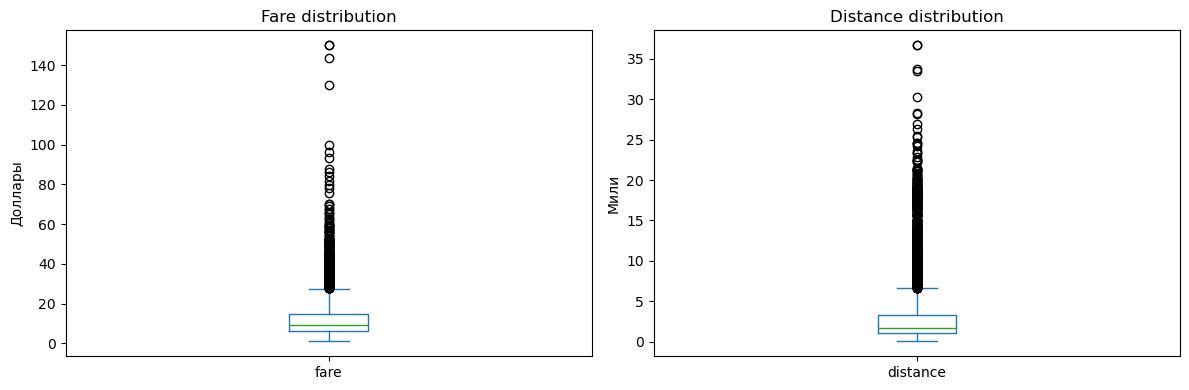

Средняя стоимость поездки по зонам посадки (первые 10):
pickup_zone
East Flushing                   80.250000
Flushing Meadows-Corona Park    52.000000
Maspeth                         48.910000
Douglaston                      47.470000
JFK Airport                     45.307838
Howard Beach                    44.000000
Cambria Heights                 42.363333
Sunset Park West                42.220000
Springfield Gardens North       42.085000
Brighton Beach                  39.500000
Name: fare, dtype: float64
Средняя стоимость:
  В часы пик:   12.53 $
  Не в часы пик: 13.37 $
Очищенный датасет сохранён в 'taxis_cleaned.csv'
Итоговый размер: (6382, 18)
Пропуски после всех обработок:
 pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            39
pickup_zone         0
dropoff_zone        0
pickup_borough     15
dropoff_borough    30


In [4]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('taxis')
print("Размер исходных данных:", df.shape)
df.head()


df.info()


print("Пропуски до обработки:")
print(df.isnull().sum())


print("Количество полных дубликатов:", df.duplicated().sum())


df['pickup'] = pd.to_datetime(df['pickup'])
df['dropoff'] = pd.to_datetime(df['dropoff'])
print(df[['pickup', 'dropoff']].dtypes)


df['pickup_hour'] = df['pickup'].dt.hour

df['is_peak_hour'] = df['pickup_hour'].between(6, 9) | df['pickup_hour'].between(17, 20)
df['weekday'] = df['pickup'].dt.weekday        # пн=0, вс=6
df['is_weekend'] = df['weekday'].isin([5, 6])  # суббота, воскресенье

print(df[['pickup_hour', 'is_peak_hour', 'weekday', 'is_weekend']].head())


zero_dist = df[df['distance'] == 0]
print(f"Поездок с нулевым расстоянием: {len(zero_dist)}")
if len(zero_dist) > 0:
    df = df[df['distance'] > 0]
    print(f"Удалено. Новый размер: {df.shape}")


print("Пропуски в dropoff_zone до заполнения:", df['dropoff_zone'].isnull().sum())
df['dropoff_zone'] = df['dropoff_zone'].fillna('Unknown')
print("После заполнения:", df['dropoff_zone'].isnull().sum())


df['pickup_zone'] = df['pickup_zone'].fillna('Unknown')


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

df['fare'].plot.box(title='Fare distribution')
plt.ylabel('Доллары')

plt.subplot(1, 2, 2)
df['distance'].plot.box(title='Distance distribution')
plt.ylabel('Мили')

plt.tight_layout()
plt.show()


avg_fare_by_zone = df.groupby('pickup_zone')['fare'].mean().sort_values(ascending=False)
print("Средняя стоимость поездки по зонам посадки (первые 10):")
print(avg_fare_by_zone.head(10))


peak_analysis = df.groupby('is_peak_hour')['fare'].mean()
print("Средняя стоимость:")
print(f"  В часы пик:   {peak_analysis[True]:.2f} $")
print(f"  Не в часы пик: {peak_analysis[False]:.2f} $")


df.to_csv('taxis_cleaned.csv', index=False)
print(f"Очищенный датасет сохранён в 'taxis_cleaned.csv'")
print(f"Итоговый размер: {df.shape}")
print("Пропуски после всех обработок:\n", df.isnull().sum())